In [ ]:
%matplotlib inline
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn import metrics
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import scipy.stats as ss
import warnings

In [ ]:
ss = pd.read_csv("../../data/raw/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [ ]:
df_train = pd.read_csv("../../data/raw/train.csv")
df_train.pop('id')
df_test = pd.read_csv("../../data/raw/test.csv")
df_test.pop('id')

0         691369
1         691370
2         691371
3         691372
4         691373
           ...  
296297    987666
296298    987667
296299    987668
296300    987669
296301    987670
Name: id, Length: 296302, dtype: int64

Show missing percentage

In [4]:
train_missing_pc = df_train.isna().sum().sort_values(ascending=False)/len(df_train)*100
test_missing_pc = df_test.isna().sum().sort_values(ascending=False)/len(df_test)*100

miss_df = pd.DataFrame()
miss_df['train'] = train_missing_pc
miss_df['test'] = test_missing_pc
miss_df['difference'] = (train_missing_pc - test_missing_pc).round(2)
miss_df['abs_difference'] = miss_df['difference'].abs()
miss_df = miss_df.sort_values(by=["abs_difference"], ascending=False)
miss_df

,train,test,difference,abs_difference
social_media_hours,19.381112,15.996180,3.38,3.38
app_opens_per_day,11.673940,8.675271,3.00,3.00
daily_screen_time_hours,13.864376,11.065737,2.80,2.80
academic_work_impact,6.396584,8.680670,-2.28,2.28
work_study_hours,7.451592,9.374557,-1.92,1.92
notifications_per_day,9.775388,11.549365,-1.77,1.77
gaming_hours,18.343461,20.053864,-1.71,1.71
age,4.184307,5.783964,-1.60,1.60
stress_level,7.976638,6.623647,1.35,1.35
sleep_hours,6.433612,7.578417,-1.14,1.14


C:\Users\abhin\AppData\Local\Temp\ipykernel_18612\2475287653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=miss_df['difference'], y=miss_df.index,palette="viridis")


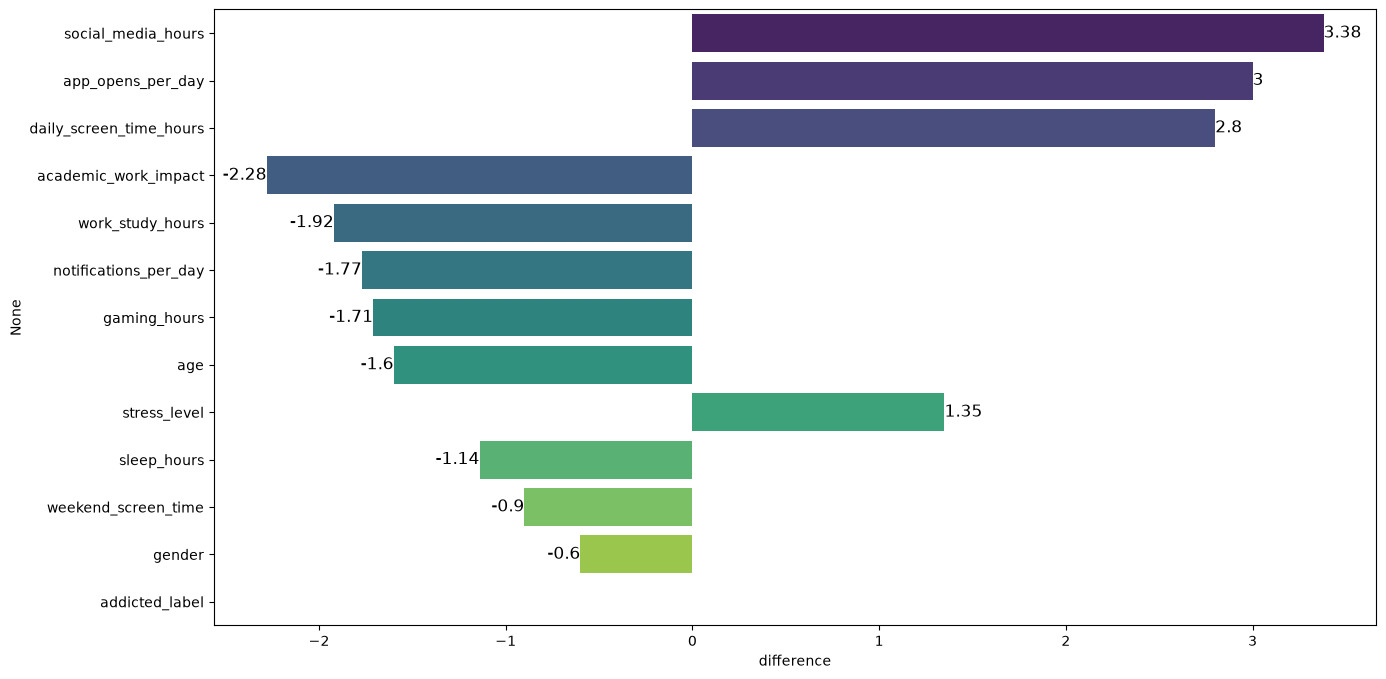

In [ ]:
plt.subplots(figsize=(15,8))
ax = sns.barplot(x=miss_df['difference'], y=miss_df.index,palette="viridis")
for c in ax.containers: 
    ax.bar_label(c, fontsize=12)

In [5]:
df_train_cols = df_train.columns
df_train_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level',
       'academic_work_impact', 'addicted_label'],
      dtype='str')

In [6]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  str    
 10  stress_level             636221 non-null  str    
 11  academic_work_impact     647145 non-null  str    
 12  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(1), str(3)
memory usage: 68.6 MB


In [9]:
def create_missing_df(df):
    df_miss = df.copy()
    cols = df_miss.columns
    for col in df_miss.columns:
        if not df_miss[col].isna().any():
            continue
        
        df_miss[f"{col}_isna"] = df_miss[col].isna()

    cols_no_target = list(set(cols) - set([target_column]))
    df_miss.drop(cols_no_target,axis=1,inplace=True)
    return df_miss

df_train_miss = create_missing_df(df_train)
df_train_miss.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   addicted_label                691369 non-null  int64
 1   age_isna                      691369 non-null  bool 
 2   daily_screen_time_hours_isna  691369 non-null  bool 
 3   social_media_hours_isna       691369 non-null  bool 
 4   gaming_hours_isna             691369 non-null  bool 
 5   work_study_hours_isna         691369 non-null  bool 
 6   sleep_hours_isna              691369 non-null  bool 
 7   notifications_per_day_isna    691369 non-null  bool 
 8   app_opens_per_day_isna        691369 non-null  bool 
 9   weekend_screen_time_isna      691369 non-null  bool 
 10  gender_isna                   691369 non-null  bool 
 11  stress_level_isna             691369 non-null  bool 
 12  academic_work_impact_isna     691369 non-null  bool 
dtypes: bool(12), int64(1)
mem

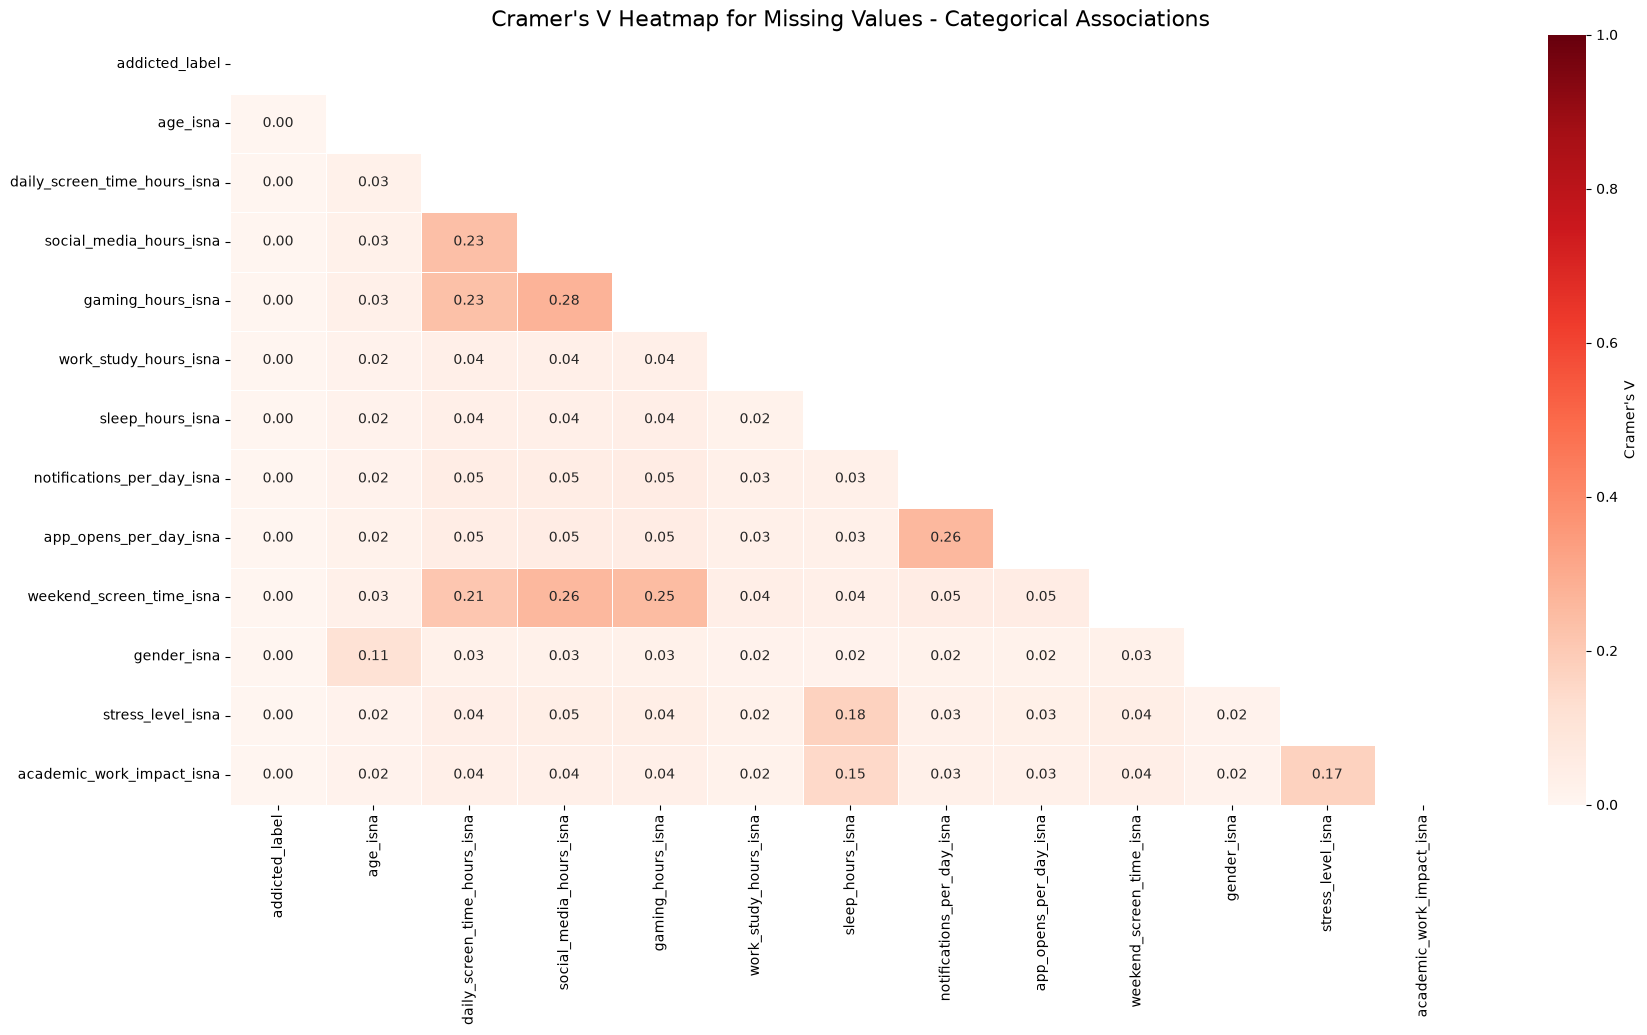

In [ ]:
def cramers_corrected_stat(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))

def cramers_heatmap(df):
    cols = df.columns.values
    n_cols = len(cols)
    v_matrix = np.zeros((n_cols, n_cols))

    for i in range(n_cols):
        for j in range(i+1, n_cols):
            crosstab = pd.crosstab(df[cols[i]], df[cols[j]]).to_numpy()
            v = cramers_corrected_stat(crosstab)
            v_matrix[i, j] = v
            v_matrix[j, i] = v

    v_df = pd.DataFrame(v_matrix, index=cols, columns=cols)

    # mask the upper triangle
    mask = np.triu(np.ones_like(v_df, dtype=bool))

    fig, ax = plt.subplots(figsize=(20, 10))
    sns.heatmap(
        v_df,
        linewidths=0.5,
        mask=mask,
        annot=True,
        fmt='.2f',
        vmin=0,
        vmax=1,
        cmap='Reds',
        cbar_kws={'label': "Cramer's V"}
    )
    plt.title("Cramer's V Heatmap for Missing Values - Categorical Associations", fontsize=16)
    plt.show()

cramers_heatmap(df_train_miss)

In [ ]:
train_cat_cols = df_train.select_dtypes(include="str").columns
df_train_with_miss = pd.concat([df_train, df_train_miss], axis=1)
df_train_with_miss.drop([target_column], axis=1, inplace=True)
df_train_with_miss.drop(train_cat_cols, axis=1, inplace=True)

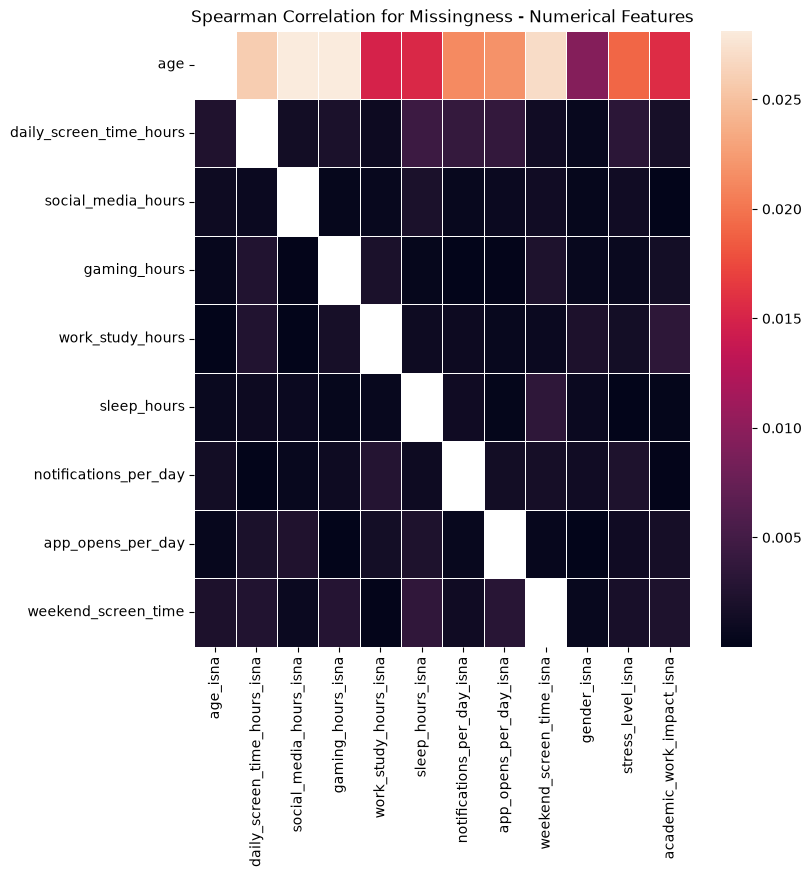

In [37]:
corr = df_train_with_miss.corr(method='spearman').abs()
corr = corr.loc[~corr.index.str.contains('_isna'), corr.columns.str.contains('_isna')]

f, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(corr, linewidths=.5)
plt.title("Spearman Correlation for Missingness - Numerical Features", fontsize=12)
plt.show()